In [26]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


In [ ]:
VAL_PATH = 'DATASET-CLASE/DATASET/val'
TEST_PATH = 'DATASET-CLASE/DATASET/test'
TRAIN_PATH = 'DATASET-CLASE/DATASET/Train'

X = [] # Características
y = [] # Etiquetas

In [13]:
def procesar (DATASET_PATH):    
    X = [] # Características
    y = [] # Etiquetas
    for label in os.listdir(DATASET_PATH):
        subcarpeta = os.path.join(DATASET_PATH, label)
        if not os.path.isdir(subcarpeta):
            break
        for img_name in os.listdir(subcarpeta):
            img_path = os.path.join(subcarpeta, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (128, 128))
            features = hog(
                img, orientations=9, 
                pixels_per_cell=(16, 16),
                cells_per_block=(2, 2),
            )
            X.append(features)
            y.append(label)
    X = np.array(X)
    y = np.array(y)
    return X, y


In [14]:
X_train, y_train = procesar(TRAIN_PATH)
X_val, y_val = procesar(VAL_PATH)
X_test, y_test = procesar(TEST_PATH)


In [ ]:
# Entrenar el modelo SVM
model = SVC()# Crear el modelo SVM
model.fit(X_train, y_train) #Entrenar el modelo

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
y_pred = model.predict(X_val) # Predecir en el conjunto de prueba
print("Accuracy:", accuracy_score(y_val, y_pred)) # Imprimir precisión

Accuracy: 0.90625


In [18]:
y_pred = model.predict(X_test) # Predecir en el conjunto de prueba
print("Accuracy:", accuracy_score(y_test, y_pred)) # Imprimir precisión
print("Report:",classification_report(y_test, y_pred)) # Informe detallado

Accuracy: 0.875
Report:               precision    recall  f1-score   support

    AAlegria       1.00      1.00      1.00         1
       ALara       0.50      1.00      0.67         1
      ASaula       1.00      1.00      1.00         1
    BPepinos       1.00      1.00      1.00         1
  CCalapucha       1.00      1.00      1.00         1
     EChuico       1.00      1.00      1.00         1
   EZambrano       1.00      1.00      1.00         1
    FJimenez       1.00      1.00      1.00         1
   HQuintero       1.00      1.00      1.00         1
     JFranco       1.00      1.00      1.00         1
     JGuerra       0.00      0.00      0.00         1
    JJimenez       0.00      0.00      0.00         1
     JTorres       0.50      1.00      0.67         1
     MMolina       1.00      1.00      1.00         1
      PTapia       1.00      1.00      1.00         1
 RPuruncajas       1.00      1.00      1.00         1

    accuracy                           0.88        16
  

c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [22]:
def predecir_persona(ruta, model):

    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2)
    )

    features = features.reshape(1,-1)

    pred = model.predict(features)[0]

    return pred

👤 Predicción: JFranco


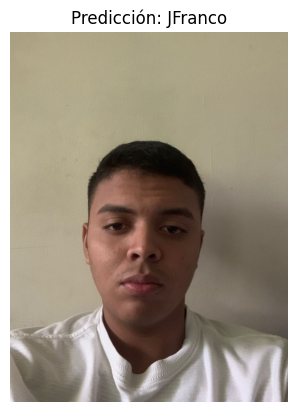

In [28]:
ruta_imagen = "image.png"

persona = predecir_persona(ruta_imagen, model)

print("👤 Predicción:", persona)

img = cv2.imread(ruta_imagen)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Predicción: {persona}")
plt.axis("off")
plt.show()